In [1]:
from func_parallel import run_model_test

import xarray as xr

import numpy as np

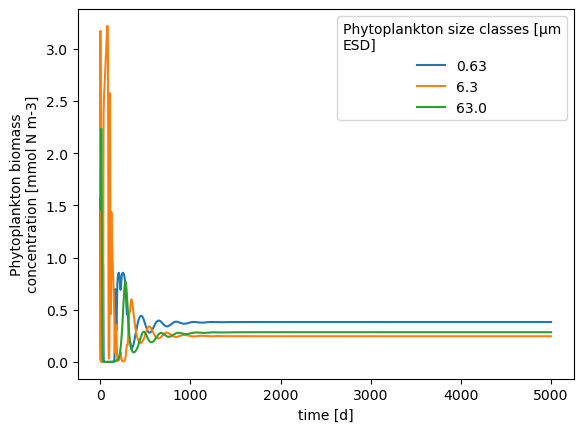

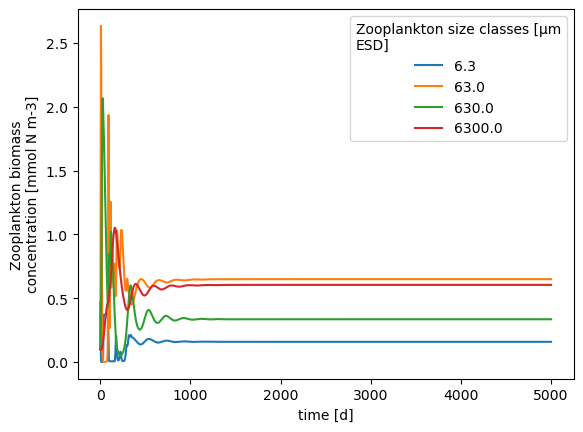

In [2]:
import matplotlib.pyplot as plt
out2 = run_model_test({'N0__value':0.00325,'GGE__gge':0.3103448275862069,'HigherOrderMortality__rate': 0.01120408})#.Phytoplankton__biomass.plot.line(x='time')
out2.Phytoplankton__biomass.plot.line(x='time')
plt.show()
out2.Zooplankton__biomass.plot.line(x='time')

In [3]:
from func_parallel import run_model_test_stability
run_model_test_stability({'N0__value':0.00325,'GGE__gge':0.3103448275862069,'HigherOrderMortality__rate': 0.01120408})#.Phytoplankton__biomass.plot.line(x='time')

[INFO] Initial state dimension: 8
[INFO] Initial state: [1.  1.5 1.5 1.5 0.1 0.1 0.1 0.1]
[INFO] Steady state found with residual norm: 1.63e-09
  Steady state: [ 6.82999673e-01  9.72176983e-01  2.20052631e-02 -1.50710264e-08
 -2.20052631e-02  9.76525455e-01  1.70002617e-11  4.21493403e-11]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 8 eigenvalues


<xarray.Dataset> Size: 2kB
Dimensions:                                         (zoo: 4, time: 2, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 16B 0.0 1.0
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/57)
    Core__solver_type                               <U9 36B 'stability'
    GGE__R                                          float64 8B 0.45
    GGE__alpha                                      float64 8B 0.7
    GGE__assimilated_consumer                       <U1 4B 'Z'
    GGE__assimilation_value                         (zoo, time) float64 64B 0...
    GGE__egested_detritus                           <U1 4B 'N'
    ...                                              ...
    Phytoplankton__phyto_index                      (phyto) float64 24B 0.63 ...
    Time__time_input                                (time) int64 16B 0 1
    Zooplankton__biomass                            (zoo, time) float64 64B 0...
    Zooplankton__biomass_init                       (zoo) float64 32B 0.1 ......
    Zooplankton__biomass_label                      <U1 4B 'Z'
    Zooplankton__zoo_index                          (zoo) float64 32B 6.3 ......

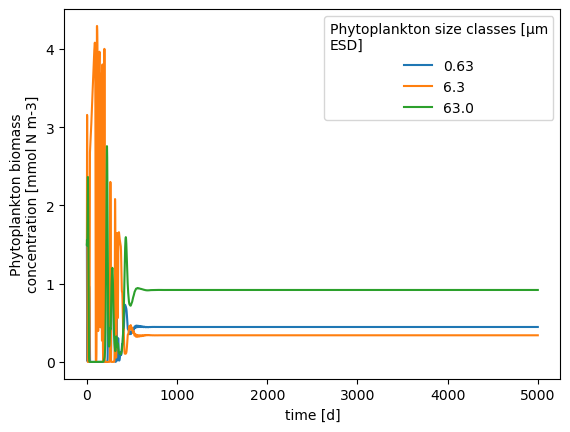

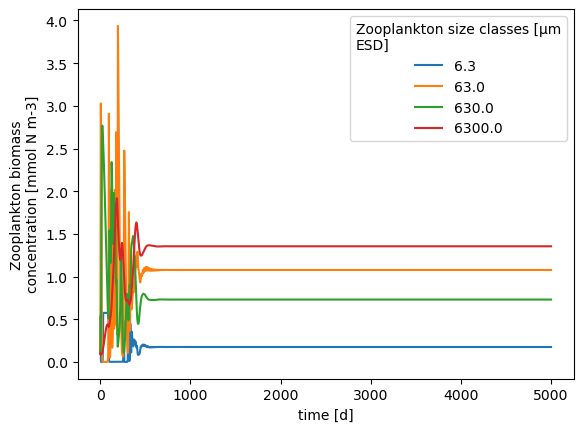

In [4]:
import matplotlib.pyplot as plt
outx = run_model_test({'GGE__gge':0.3705050505050505,'HigherOrderMortality__rate': 0.026118181818181818})#.Phytoplankton__biomass.plot.line(x='time')
outx.Phytoplankton__biomass.plot.line(x='time')
plt.show()
outx.Zooplankton__biomass.plot.line(x='time')

In [18]:
Phyto_init2 = out2.Phytoplankton__biomass.isel(time=slice(4000,5000)).mean(dim='time').values
Zoo_init2 = out2.Zooplankton__biomass.isel(time=slice(4000,5000)).mean(dim='time').values

In [19]:
Phyto_init = outx.Phytoplankton__biomass.isel(time=slice(4000,5000)).mean(dim='time').values
Zoo_init = outx.Zooplankton__biomass.isel(time=slice(4000,5000)).mean(dim='time').values

In [20]:
from func_parallel import model_setup_fs, model

In [21]:
input_pars = {'Phytoplankton__biomass_init':Phyto_init,
              'Zooplankton__biomass_init':Zoo_init,
    'GGE__gge':0.3705050505050505,'HigherOrderMortality__rate': 0.026118181818181818}

In [22]:
with model:
        model_out = model_setup_fs.xsimlab.update_vars(input_vars=input_pars).xsimlab.run()

InitState [0.         1.         0.44666331 0.3404672  0.91985636 0.17493329
 1.07698726 0.73048563 1.3544284 ]
[INFO] Steady state found with residual norm: 1.52176159714813e-12
Residuals: [ 0.00000000e+00  1.31084033e-12 -3.60905750e-13 -5.41178213e-13
 -4.17429979e-13  4.66293670e-15  3.63598041e-15  6.81399381e-15
  6.93889390e-18]
YSTEADY [0.         1.29192474 0.44666332 0.3404672  0.91985636 0.17493329
 1.07698726 0.73048563 1.3544284 ]


In [115]:
input_pars2 = {'Phytoplankton__biomass_init':Phyto_init2,
              'Zooplankton__biomass_init':Zoo_init2,
               'N0__value':0.00325,'GGE__gge':0.3103448275862069,'HigherOrderMortality__rate': 0.01120408}

with model:
        model_out2 = model_setup_fs.xsimlab.update_vars(input_vars=input_pars2).xsimlab.run()

InitState [0.         1.         0.38242593 0.24580962 0.28472762 0.15748729
 0.64883993 0.33438341 0.60412051]
[INFO] Steady state found with residual norm: 1.7678142681578257e-12
Residuals: [ 0.00000000e+00  7.49289519e-13 -7.34440286e-13  2.98455705e-13
 -1.24577085e-12 -7.02216063e-15  5.83179338e-13  2.07753953e-13
 -1.56125113e-17]
YSTEADY [0.         0.34597655 0.38242594 0.24580962 0.28472762 0.15748729
 0.64883993 0.33438341 0.60412052]


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

import matplotlib.dates as mdates
import datetime

In [25]:
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")

In [26]:
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")

CARIACO.ui = CARIACO.ui.astype('category').cat.reorder_categories(['relaxed', 'weak','moderate', 'strong'])

CARIACO.upwelling = CARIACO.upwelling.astype('category').cat.reorder_categories(['relaxed', 'upwelling'])

In [27]:
# first split entire data frame by cluster time points from MS2

#GroupRed = extractGroups(year1="1996-01-01", year2="2003-12-31", year3="2014-01-01", year4="2016-12-31") #2016-12-31
#GroupBlue = extractGroups(year1="2004-01-01", year2="2013-12-31", year3="2017-06-01", year4="2017-12-31")

cluster1_mask = (CARIACO.date.dt.date>datetime.date(1996, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2003, 12, 31)) | \
                 (CARIACO.date.dt.date>datetime.date(2014, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2016, 12, 31))

cluster2_mask = (CARIACO.date.dt.date>datetime.date(2004, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2013, 12, 31))

CARIACO["cluster"] = 'none'
CARIACO.loc[cluster1_mask, "cluster"] = 'cluster 1'
CARIACO.loc[cluster2_mask, "cluster"] = 'cluster 2'

Text(0.5, 0, 'Cluster')

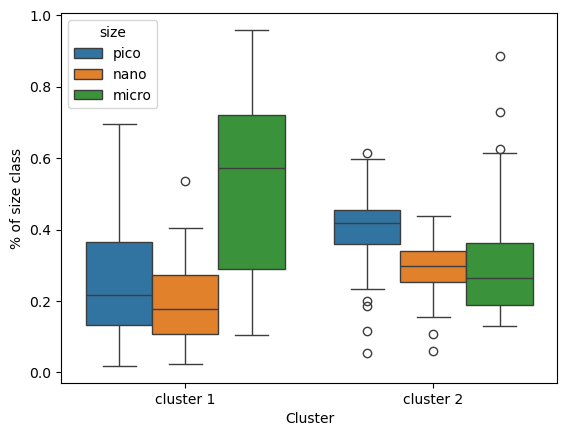

In [28]:
meltCar2 = pd.melt(CARIACO, id_vars=('date','cluster'), value_vars=('pico', 'nano', 'micro'), var_name='size')
sns.boxplot(data=meltCar2[meltCar2.cluster!='none'], x='cluster', y='value', hue='size')
plt.ylabel("% of size class")
plt.xlabel("Cluster")

Text(0.5, 0, 'Cluster')

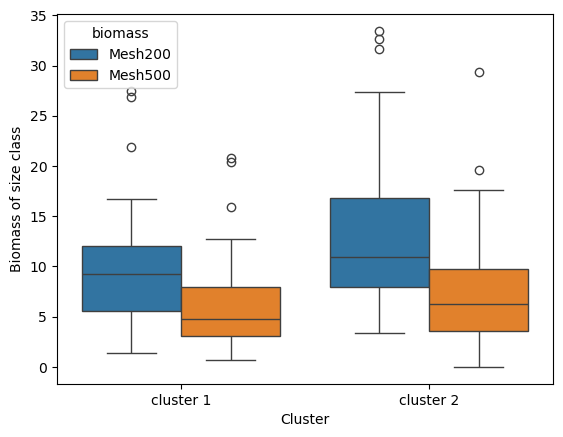

In [29]:
meltCar3 = pd.melt(CARIACO, id_vars=('date','cluster'), value_vars=('Mesh200', 'Mesh500'), var_name='biomass')
sns.boxplot(data=meltCar3[meltCar3.cluster!='none'], x='cluster', y='value', hue='biomass')
plt.ylabel("Biomass of size class")
plt.xlabel("Cluster")

In [103]:
print(meltCar3)

          date    cluster  biomass     value
0   1995-11-01       none  Mesh200       NaN
1   1995-12-01       none  Mesh200       NaN
2   1996-01-01       none  Mesh200       NaN
3   1996-02-01  cluster 1  Mesh200       NaN
4   1996-03-01  cluster 1  Mesh200       NaN
..         ...        ...      ...       ...
505 2016-09-01  cluster 1  Mesh500  7.911480
506 2016-10-01  cluster 1  Mesh500       NaN
507 2016-11-01  cluster 1  Mesh500       NaN
508 2016-12-01  cluster 1  Mesh500  1.265940
509 2017-01-01       none  Mesh500  0.966536

[510 rows x 4 columns]


In [31]:
phyto_out = model_out.isel(time=1).Phytoplankton__biomass 
percentage_phyto_out = (phyto_out / phyto_out.sum()) 

percentage_phyto_out

phyto_out2 = model_out2.isel(time=1).Phytoplankton__biomass 
percentage_phyto_out2 = (phyto_out2 / phyto_out2.sum()) 

percentage_phyto_out2

<xarray.DataArray 'Phytoplankton__biomass' (phyto: 3)> Size: 24B
array([0.41888429, 0.26924374, 0.31187196])
Coordinates:
  * phyto    (phyto) float64 24B 0.63 6.3 63.0
    time     float64 8B 0.0

In [100]:
percentage_zoo_out
(percentage_zoo_out[0]+percentage_zoo_out[1]).values.max()

np.float64(0.3751820823503733)

In [1]:
zoo_out

NameError: name 'zoo_out' is not defined

In [35]:
zoo_out = model_out.isel(time=1).Zooplankton__biomass 
percentage_zoo_out = (zoo_out / zoo_out.sum()) 

Mesh200 = (percentage_zoo_out[0]+percentage_zoo_out[1]).values.max()

Mesh500 = percentage_zoo_out[2].values.max()

In [47]:
zoo_out2 = model_out2.isel(time=1).Zooplankton__biomass 
percentage_zoo_out2 = (zoo_out2 / zoo_out2.sum()) 

Mesh200_2 = (percentage_zoo_out2[0]+percentage_zoo_out2[1]).values.max()

Mesh500_2 = percentage_zoo_out2[2].values.max()

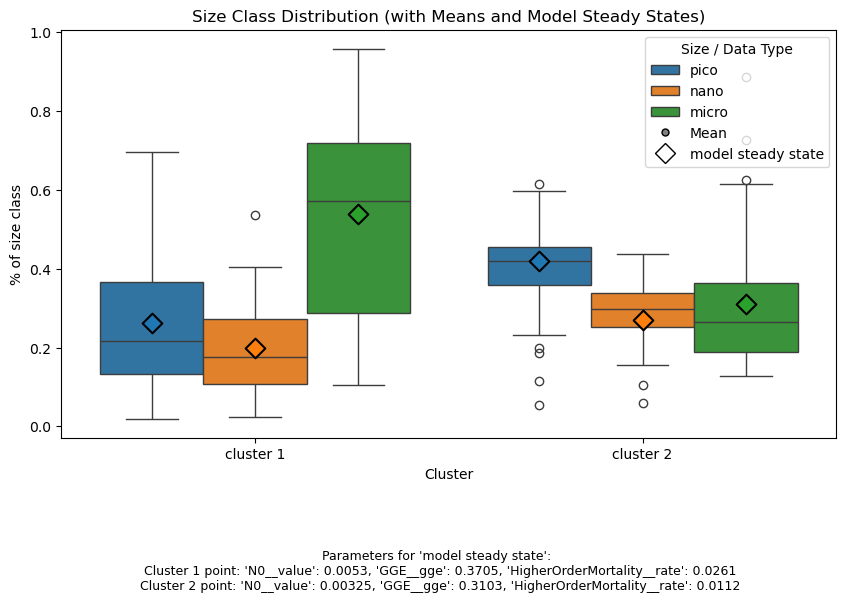

In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D # Needed for custom legend handles

# --- 1. Prepare DataFrames ---
df_cluster1_points = pd.DataFrame({
    'cluster': 'cluster 1',           # Must match the x-axis label in meltCar2
    'value': percentage_phyto_out,    # Your relative biomass values [phyto1, phyto2, phyto3]
    'size': ['pico', 'nano', 'micro'] # Must match the 'hue' categories in meltCar2
})

# Create DataFrame for the second model output (to be plotted on 'cluster 2')
df_cluster2_points = pd.DataFrame({
    'cluster': 'cluster 2',           # Must match the x-axis label in meltCar2
    'value': percentage_phyto_out2,   # Your relative biomass values [phyto1, phyto2, phyto3]
    'size': ['pico', 'nano', 'micro'] # Must match the 'hue' categories in meltCar2
})

# --- Store Parameters for Caption ---
params_cluster1 = "'N0__value': 0.0053, 'GGE__gge': 0.3705, 'HigherOrderMortality__rate': 0.0261"
params_cluster2 = "'N0__value': 0.00325, 'GGE__gge': 0.3103, 'HigherOrderMortality__rate': 0.0112"

# --- 2. Plotting ---
plt.figure(figsize=(10, 6))

# --- Plot your original boxplot with means ---
ax = sns.boxplot(
    data=meltCar2[meltCar2.cluster != 'none'],
    x='cluster',
    y='value',
    hue='size',
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"grey",
               "markeredgecolor":"black", "markersize":"2"}
)

# --- Overlay cluster 1 points ---
sns.stripplot(
    data=df_cluster1_points,
    x='cluster',
    y='value',
    hue='size',
    ax=ax,
    dodge=True,
    jitter=False,
    marker='D', # Diamond
    size=10,
    linewidth=1.5,
    edgecolor='black',
    facecolor='none',
    legend=False
)

# --- Overlay cluster 2 points (using the same marker) ---
sns.stripplot(
    data=df_cluster2_points,
    x='cluster',
    y='value',
    hue='size',
    ax=ax,
    dodge=True,
    jitter=False,
    marker='D', # Diamond
    size=10,
    linewidth=1.5,
    edgecolor='black',
    facecolor='none',
    legend=False
)

# --- 3. Custom Legend (Revised) ---
handles, labels = ax.get_legend_handles_labels()
num_hues = len(meltCar2['size'].unique())

# Handle for the mean
mean_handle = Line2D([0], [0], marker='o', color='w', label='Mean',
                     markerfacecolor='grey', markeredgecolor='black', markersize=5)

# --- Corrected Handle: Diamond marker labeled 'model steady state' ---
model_output_handle = Line2D([0], [0], marker='D', color='w', label='model steady state',
                             markerfacecolor='none', markeredgecolor='black', markersize=10)

# Combine handles/labels: Boxplot hues + Mean + Model Output
ax.legend(handles=handles[0:num_hues] + [mean_handle, model_output_handle], # Remove cluster2 handle
          labels=labels[0:num_hues] + ['Mean', 'model steady state'],     # Correct label
          title='Size / Data Type')

# --- 4. Final Touches & Caption ---
plt.ylabel("% of size class")
plt.xlabel("Cluster")
plt.title("Size Class Distribution (with Means and Model Steady States)") # Updated title

# Add caption below the plot
# Adjust parameter labels in caption to match legend
caption = f"Parameters for 'model steady state':\n  Cluster 1 point: {params_cluster1}\n  Cluster 2 point: {params_cluster2}"
plt.figtext(0.5, -0.05, caption, wrap=True, horizontalalignment='center', fontsize=9)

plt.subplots_adjust(bottom=0.2) # Make space for the caption

plt.show()

Text(0.5, 0, 'Cluster')

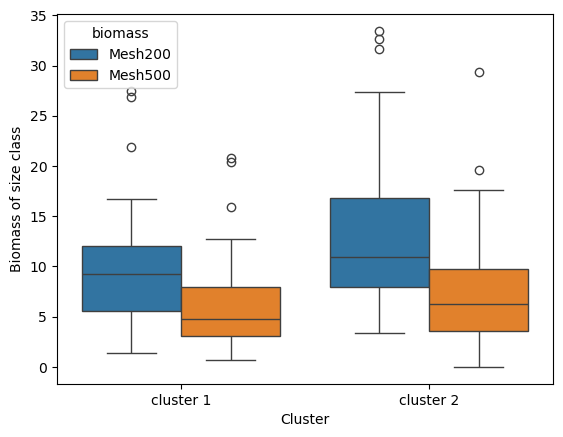

In [109]:
meltCar3 = pd.melt(CARIACO, id_vars=('date','cluster'), value_vars=('Mesh200', 'Mesh500'), var_name='biomass')
sns.boxplot(data=meltCar3[meltCar3.cluster!='none'], x='cluster', y='value', hue='biomass')
plt.ylabel("Biomass of size class")
plt.xlabel("Cluster")

Maximum absolute biomass found: 33.4458


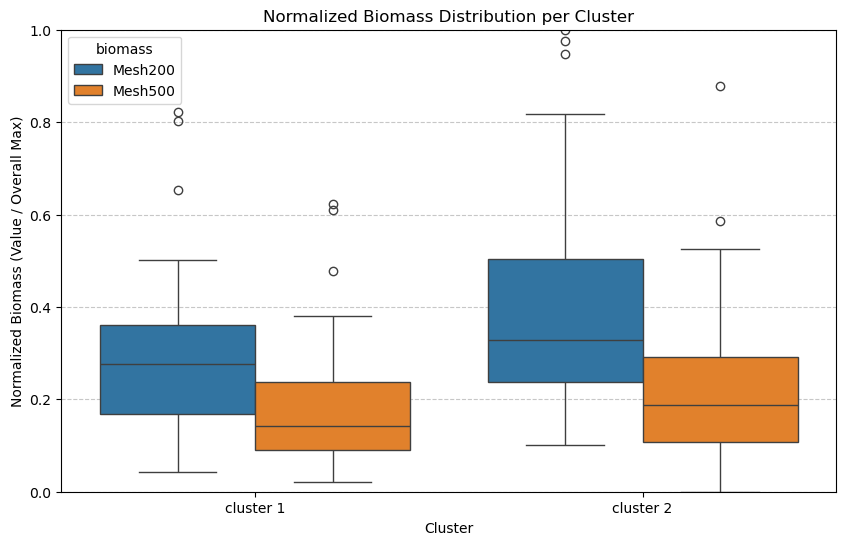

In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

# --- Assume meltCar3 DataFrame exists ---
# meltCar3 = pd.melt(CARIACO, id_vars=('date','cluster'), value_vars=('Mesh200', 'Mesh500'), var_name='biomass')

# --- 1. Find the Maximum Absolute Biomass ---
# Filter out the 'none' cluster first
filtered_data = meltCar3[meltCar3.cluster != 'none']
# Find the maximum value in the 'value' column, ignoring NaNs
max_biomass = filtered_data['value'].max(skipna=True) 

print(f"Maximum absolute biomass found: {max_biomass}")

# --- 2. Normalize by the Overall Maximum ---
# Divide every 'value' by the single max_biomass. 
# Return NaN if max_biomass is zero or NaN to avoid errors.
if max_biomass > 0 and pd.notna(max_biomass):
    meltCar3['normalized_value'] = meltCar3['value'] / max_biomass
else:
    # Handle edge case where max_biomass is zero or NaN
    meltCar3['normalized_value'] = np.nan 

# --- 3. Create the Boxplot with Normalized Values ---
plt.figure(figsize=(10, 6)) 
sns.boxplot(
    data=meltCar3[meltCar3.cluster != 'none'], # Use the filtered data again for plotting
    x='cluster',
    y='normalized_value', # Plot the normalized values
    hue='biomass'
)

# --- 4. Set Labels and Title ---
plt.ylabel("Normalized Biomass (Value / Overall Max)") # Updated Y-axis label
plt.xlabel("Cluster")
plt.title("Normalized Biomass Distribution per Cluster") # Updated title
plt.ylim(0, 1) # Normalized values are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.show()

# Optional: Clean up intermediate column
# meltCar3 = meltCar3.drop(columns=['normalized_value'])

--- Normalizing meltCar3 data ---
Maximum absolute biomass found: 33.4458
--- Normalization complete ---


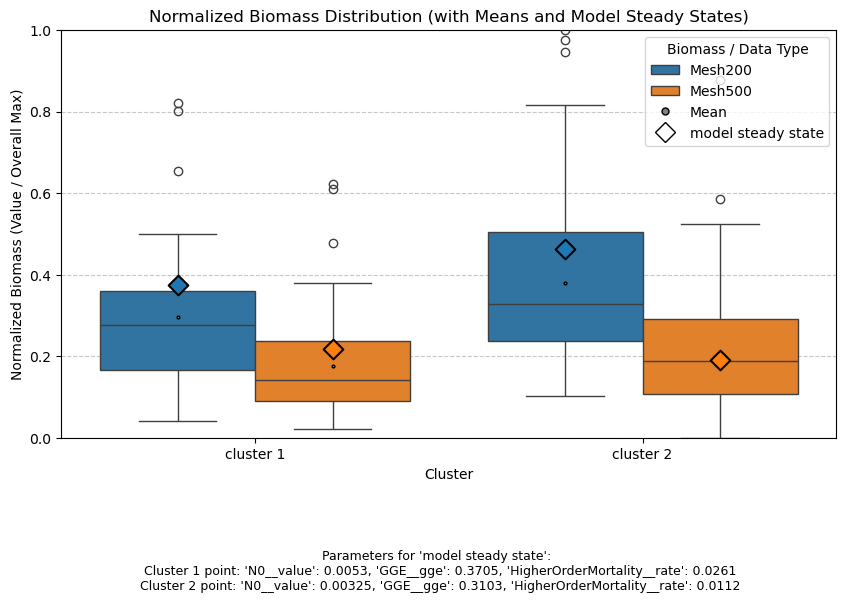

In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D # Needed for custom legend handles

# --- ASSUMPTIONS ---
# This script assumes the following variables already exist in your environment:
# - meltCar3: pd.DataFrame with columns ['date', 'cluster', 'value', 'biomass']
# - Mesh200, Mesh500: Model output values for cluster 1
# - Mesh200_2, Mesh500_2: Model output values for cluster 2
# - params_cluster1, params_cluster2: String captions for parameters
# ---------------


# --- 1. NORMALIZE meltCar3 DATA ---
# This block is from your normalization script.
print("--- Normalizing meltCar3 data ---")
# Filter out the 'none' cluster first
filtered_data = meltCar3[meltCar3.cluster != 'none']
# Find the maximum value in the 'value' column, ignoring NaNs
max_biomass = filtered_data['value'].max(skipna=True)

print(f"Maximum absolute biomass found: {max_biomass}")

# Normalize by the Overall Maximum
# This creates the 'normalized_value' column
if max_biomass > 0 and pd.notna(max_biomass):
    meltCar3['normalized_value'] = meltCar3['value'] / max_biomass
else:
    # Handle edge case where max_biomass is zero or NaN
    meltCar3['normalized_value'] = np.nan
print("--- Normalization complete ---")


# --- 2. Prepare DataFrames for Model Points ---
# (This section is unchanged from your code)
df_cluster1_points = pd.DataFrame({
    'cluster': 'cluster 1',            # Must match an x-axis label in meltCar3
    'value': [Mesh200, Mesh500],       # Your two relative biomass values
    'biomass': ['Mesh200', 'Mesh500']  # Must match the 'hue' categories in meltCar3
})

# Create DataFrame for the second model output (to be plotted on 'cluster 2')
df_cluster2_points = pd.DataFrame({
    'cluster': 'cluster 2',            # Must match an x-axis label in meltCar3
    'value': [Mesh200_2, Mesh500_2],   # Your two relative biomass values
    'biomass': ['Mesh200', 'Mesh500']  # Must match the 'hue' categories in meltCar3
})


# --- 3. Plotting ---
plt.figure(figsize=(10, 6))

# --- Plot your original boxplot with means ---
# **MODIFIED** to use 'normalized_value' on the y-axis
ax = sns.boxplot(
    data=meltCar3[meltCar3.cluster != 'none'],
    x='cluster',
    y='normalized_value', # <-- CHANGED from 'value'
    hue='biomass',
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"grey",
               "markeredgecolor":"black", "markersize":"2"}
)

# --- Overlay cluster 1 points ---
# (This section is unchanged)
sns.stripplot(
    data=df_cluster1_points,
    x='cluster',
    y='value',
    hue='biomass',
    ax=ax,
    dodge=True,
    jitter=False,
    marker='D', # Diamond
    size=10,
    linewidth=1.5,
    edgecolor='black',
    facecolor='none',
    legend=False
)

# --- Overlay cluster 2 points (using the same marker) ---
# (This section is unchanged)
sns.stripplot(
    data=df_cluster2_points,
    x='cluster',
    y='value',
    hue='biomass',
    ax=ax,
    dodge=True,
    jitter=False,
    marker='D', # Diamond
    size=10,
    linewidth=1.5,
    edgecolor='black',
    facecolor='none',
    legend=False
)

# --- 4. Custom Legend (Revised) ---
# (This section is unchanged)
handles, labels = ax.get_legend_handles_labels()
# Get number of hues from the data
num_hues = len(meltCar3[meltCar3.cluster != 'none']['biomass'].unique())

# Handle for the mean
mean_handle = Line2D([0], [0], marker='o', color='w', label='Mean',
                     markerfacecolor='grey', markeredgecolor='black', markersize=5)

# --- Corrected Handle: Diamond marker labeled 'model steady state' ---
model_output_handle = Line2D([0], [0], marker='D', color='w', label='model steady state',
                             markerfacecolor='none', markeredgecolor='black', markersize=10)

# Combine handles/labels: Boxplot hues + Mean + Model Output
ax.legend(handles=handles[0:num_hues] + [mean_handle, model_output_handle],
          labels=labels[0:num_hues] + ['Mean', 'model steady state'],
          title='Biomass / Data Type')

# --- 5. Final Touches & Caption ---
# **MODIFIED** to reflect normalization
plt.ylabel("Normalized Biomass (Value / Overall Max)") # <-- CHANGED
plt.xlabel("Cluster")
plt.title("Normalized Biomass Distribution (with Means and Model Steady States)")

# **ADDED** from your normalization script
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add caption below the plot
# (This section is unchanged)
caption = f"Parameters for 'model steady state':\n  Cluster 1 point: {params_cluster1}\n  Cluster 2 point: {params_cluster2}"
plt.figtext(0.5, -0.05, caption, wrap=True, horizontalalignment='center', fontsize=9)

plt.subplots_adjust(bottom=0.2) # Make space for the caption

plt.show()

# Optional: Clean up intermediate column
# meltCar3 = meltCar3.drop(columns=['normalized_value'])

In [112]:
import numpy as np

# --- 1. Filter out the 'none' cluster ---
# We do this first so the 'none' values don't affect the mean calculation.
filtered_data = meltCar3[meltCar3.cluster != 'none'].copy()

# --- 2. Calculate the mean value for each cluster ---
# .transform('mean') calculates the mean for each cluster and
# maps that single value back to every row in that cluster.
cluster_mean_divisor = filtered_data.groupby('cluster')['value'].transform('mean')

# --- 3. Apply the cluster mean to the filtered data ---
filtered_data['normalized_value'] = filtered_data['value'] / cluster_mean_divisor

# --- 4. Merge the normalized values back into the original DataFrame ---
# This ensures your 'meltCar3' DataFrame has the new column,
# and rows for the 'none' cluster will have NaN for this value.
meltCar3x = meltCar3.merge(
    filtered_data[['normalized_value']],
    left_index=True,
    right_index=True,
    how='left'
)


# Your 'meltCar3' DataFrame now has the 'normalized_value' column
# ready for plotting.
print("DataFrame with 'normalized_value' (head):")
print(meltCar3x.head())
meltCar3x

DataFrame with 'normalized_value' (head):
        date    cluster  biomass  value  normalized_value
0 1995-11-01       none  Mesh200    NaN               NaN
1 1995-12-01       none  Mesh200    NaN               NaN
2 1996-01-01       none  Mesh200    NaN               NaN
3 1996-02-01  cluster 1  Mesh200    NaN               NaN
4 1996-03-01  cluster 1  Mesh200    NaN               NaN


,date,cluster,biomass,value,normalized_value
0,1995-11-01,none,Mesh200,NaN,NaN
1,1995-12-01,none,Mesh200,NaN,NaN
2,1996-01-01,none,Mesh200,NaN,NaN
3,1996-02-01,cluster 1,Mesh200,NaN,NaN
4,1996-03-01,cluster 1,Mesh200,NaN,NaN
...,...,...,...,...,...
505,2016-09-01,cluster 1,Mesh500,7.911480,0.996554
506,2016-10-01,cluster 1,Mesh500,NaN,NaN
507,2016-11-01,cluster 1,Mesh500,NaN,NaN
508,2016-12-01,cluster 1,Mesh500,1.265940,0.159462


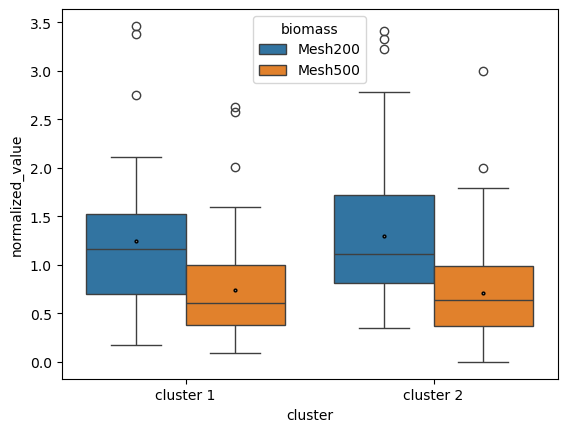

In [114]:
# --- Plot your original boxplot with means ---
# **MODIFIED** to use 'normalized_value' on the y-axis
ax = sns.boxplot(
    data=meltCar3x[meltCar3x.cluster != 'none'],
    x='cluster',
    y='normalized_value', # <-- CHANGED from 'value'
    hue='biomass',
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"grey",
               "markeredgecolor":"black", "markersize":"2"}
)